In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

columns = ["sampling_strategy", "sample_size_per_dim", "n_instances_train", "n_runs_train", "n_feval_train", "accuracy_median_mean", "accuracy_allruns_mean", "cv_instance_median_mean", "cv_function_median_mean"]

In [2]:
def plot_cv_vs_accuracy(df, output_path=None, figsize=(16, 18), dpi=180,
                        jitter_seed=42):
    """
    Plot feature CV vs classification accuracy by training budget.

    One subplot per sampling strategy, with jittered individual points.
    Colors encode sample_size_per_dim, markers encode n_instances_train.
    Filled markers = accuracy, open markers = CV.

    Accepts both per-fold DataFrames (with 'accuracy_allruns' column)
    and aggregated DataFrames (with 'accuracy_allruns_mean' column).

    Parameters
    ----------
    df : pd.DataFrame
        Results table.
    output_path : str or Path, optional
        Base path (without extension) to save .png and .pdf.
    figsize : tuple
        Figure size (width, height).
    dpi : int
        Resolution for the .png output.
    jitter_seed : int
        Seed for the horizontal jitter RNG.

    Returns
    -------
    fig, axes
    """
    # Support both column naming conventions
    acc_col = ('accuracy_allruns' if 'accuracy_allruns' in df.columns
               else 'accuracy_allruns_mean')
    cv_col = 'cv_instance_median_median'

    strategies = sorted(df['sampling_strategy'].unique().tolist())
    fevals_sorted = sorted(df['n_feval_train'].unique())
    n_fevals = len(fevals_sorted)
    feval_to_x = {f: i for i, f in enumerate(fevals_sorted)}

    # Color map: sample_size_per_dim
    sample_sizes = sorted(df['sample_size_per_dim'].unique())
    size_colors = {
        25: '#e41a1c',
        50: '#377eb8',
        75: '#4daf4a',
        100: '#984ea3',
    }
    _fallback_colors = ['#ff7f00', '#a65628', '#f781bf', '#999999']
    for i, s in enumerate(sample_sizes):
        if s not in size_colors:
            size_colors[s] = _fallback_colors[i % len(_fallback_colors)]

    # Marker map: n_instances_train
    instance_counts = sorted(df['n_instances_train'].unique())
    instance_markers = {
        1: 'o',
        5: 's',
        10: 'D',
        20: '^',
    }
    _fallback_markers = ['v', 'P', 'X', '*']
    for i, n in enumerate(instance_counts):
        if n not in instance_markers:
            instance_markers[n] = _fallback_markers[i % len(_fallback_markers)]

    n_strategies = len(strategies)
    fig, axes = plt.subplots(n_strategies, 1, figsize=figsize,
                             sharex=True, sharey=True)
    if n_strategies == 1:
        axes = [axes]
    fig.subplots_adjust(hspace=0.12, left=0.07, right=0.95,
                        top=0.91, bottom=0.08)

    rng = np.random.default_rng(jitter_seed)

    for ax_idx, strat in enumerate(strategies):
        ax = axes[ax_idx]
        sub = df[df['sampling_strategy'] == strat]

        for _, row in sub.iterrows():
            x_base = feval_to_x[row['n_feval_train']]
            color = size_colors[row['sample_size_per_dim']]
            marker = instance_markers[row['n_instances_train']]

            jx_cv = x_base - 0.15 + rng.uniform(-0.06, 0.06)
            jx_acc = x_base + 0.15 + rng.uniform(-0.06, 0.06)

            # CV: open marker
            ax.scatter(jx_cv, row[cv_col],
                       facecolors='none', edgecolors=color,
                       marker=marker, s=30, linewidths=1,
                       alpha=0.7, zorder=3)
            # Accuracy: filled marker
            ax.scatter(jx_acc, row[acc_col],
                       facecolors=color, edgecolors=color,
                       marker=marker, s=30, linewidths=0.5,
                       alpha=0.7, zorder=3)

        ax.set_ylim(0, 1)
        ax.set_yticks(np.arange(0, 1.1, 0.1))
        ax.set_ylabel('')
        ax.set_title(strat, fontsize=11, fontweight='bold', loc='left',
                     pad=4)
        ax.grid(axis='y', alpha=0.3, linewidth=0.5)
        ax.grid(axis='x', alpha=0.15, linewidth=0.3)

    # X-axis labels
    axes[-1].set_xticks(range(n_fevals))
    feval_labels = [f'{f // 1000}k' if f >= 1000 else str(f)
                    for f in fevals_sorted]
    axes[-1].set_xticklabels(feval_labels, rotation=45, ha='right',
                             fontsize=8)
    axes[-1].set_xlabel('Function evaluations (training budget)',
                        fontsize=11)

    fig.text(0.02, 0.5, 'Value [0, 1]', va='center',
             rotation='vertical', fontsize=11)

    # --- Legend ---
    legend_elements = []

    # Metric type (filled vs open)
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
               markersize=7, label='Accuracy (filled)', alpha=0.8))
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
               markeredgecolor='grey', markeredgewidth=1,
               markersize=7, label='CV (open)', alpha=0.8))

    # Spacer
    legend_elements.append(
        Line2D([0], [0], color='w', label=''))

    # Colors: sample_size_per_dim
    for s in sample_sizes:
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=size_colors[s], markersize=7,
                   label=f'sample_size={s}'))

    # Spacer
    legend_elements.append(
        Line2D([0], [0], color='w', label=''))

    # Markers: n_instances_train
    for n in instance_counts:
        legend_elements.append(
            Line2D([0], [0], marker=instance_markers[n], color='w',
                   markerfacecolor='grey', markersize=7,
                   label=f'n_instances={n}'))

    fig.legend(handles=legend_elements, loc='upper center',
               ncol=len(legend_elements), fontsize=8,
               frameon=True, fancybox=False, edgecolor='#cccccc',
               bbox_to_anchor=(0.5, 0.98), columnspacing=1.2,
               handletextpad=0.4)

    fig.suptitle('Feature CV vs Classification Accuracy by Training Budget',
                 fontsize=14, fontweight='bold', y=1.0)

    if output_path is not None:
        from pathlib import Path
        output_path = Path(output_path)
        fig.savefig(output_path.with_suffix('.png'), dpi=dpi,
                    bbox_inches='tight', facecolor='white')
        fig.savefig(output_path.with_suffix('.pdf'),
                    bbox_inches='tight', facecolor='white')

    plt.show()
    return fig, axes

## Dimension 2

In [3]:
table_pkl_dim2 = Path("~/t7ssd/featELA/dim2featELA/classification_subsample/subsample_results_table.pkl")
df = pd.read_pickle(table_pkl_dim2)
df.columns

Index(['dimension', 'sampling_strategy', 'sample_size_per_dim',
       'n_instances_train', 'n_runs_train', 'n_feval_train', 'fold',
       'n_features', 'n_omitted_features', 'omitted_features',
       'cv_instance_median_mean', 'cv_instance_median_median',
       'cv_function_median_mean', 'cv_function_median_median',
       'cv_training_folds_median_mean', 'cv_training_folds_median_median',
       'accuracy_median', 'accuracy_allruns', 'consistency'],
      dtype='str')

| Column | Description |
|--------|-------------|
| `dimension` | Problem dimensionality (e.g. 2 or 5). |
| `sampling_strategy` | Sampling strategy used (e.g. `ilhs`, `cma_random`), parsed from the config key. |
| `sample_size_per_dim` | Base sample size per dimension. Actual sample size = `sample_size_per_dim × dimension`. |
| `feval_training` | Total function evaluations for training: `(sample_size_per_dim × dim) × 24 functions × 80 instances × n_runs_train`. |
| `runs_training_per_instance` | Number of independent runs per instance used for training (e.g. 1–30). |
| `cv_instance_median_mean` | Per-instance CV: for each feature, take the median CV across all 24×100 instances, then the **mean** across features. |
| `cv_instance_median_median` | Per-instance CV: for each feature, take the median CV across all 24×100 instances, then the **median** across features. |
| `cv_function_median_mean` | Per-function CV: for each feature, take the median CV across 24 functions, then the **mean** across features. |
| `cv_function_median_median` | Per-function CV: for each feature, take the median CV across 24 functions, then the **median** across features. |
| `cv_training_folds_function_median_mean` | Training-set CV: for each feature, take the median CV across 24 functions × 5 folds, then the **mean** across features. |
| `cv_training_folds_function_median_median` | Training-set CV: for each feature, take the median CV across 24 functions × 5 folds, then the **median** across features. |
| `accuracy_median_mean` | Mean 5-fold classification accuracy using median-aggregated features per test instance. |
| `accuracy_median_sd` | Std dev of 5-fold classification accuracy (median-aggregated features)|
| `accuracy_allruns_mean` | Mean 5-fold classification accuracy using all individual runs per test instance. |
| `accuracy_allruns_sd` | Std dev of 5-fold classification accuracy (all runs)|

In [4]:
## Per instance cv of features, median across dataset, and mean across features
df_unique = df.drop_duplicates(subset=["sampling_strategy", "sample_size_per_dim"])
pivot = df_unique.pivot(index="sampling_strategy", columns="sample_size_per_dim",
                        values="cv_instance_median_mean")
pivot

sample_size_per_dim,25,50,75,100
sampling_strategy,,,,
cma_random,0.490284,0.467463,0.490092,0.526402
ilhs,0.211366,0.174404,0.116454,0.103149
lhs,0.291499,0.237537,0.147355,0.132414
sobol,0.240613,0.161319,0.135615,0.130909
uniform,0.319444,0.261273,0.177362,0.198552


In [5]:
df["n_feval_train"].value_counts()


n_feval_train
24000     100
72000     100
18000      75
12000      75
36000      75
120000     75
3600       50
6000       50
60000      50
48000      50
144000     50
240000     50
1200       25
30000      25
2400       25
7200       25
10800      25
54000      25
90000      25
108000     25
180000     25
216000     25
360000     25
4800       25
14400      25
96000      25
288000     25
480000     25
Name: count, dtype: int64

In [6]:
df["n_instances_train"].unique()

array([ 1,  5, 10, 20])

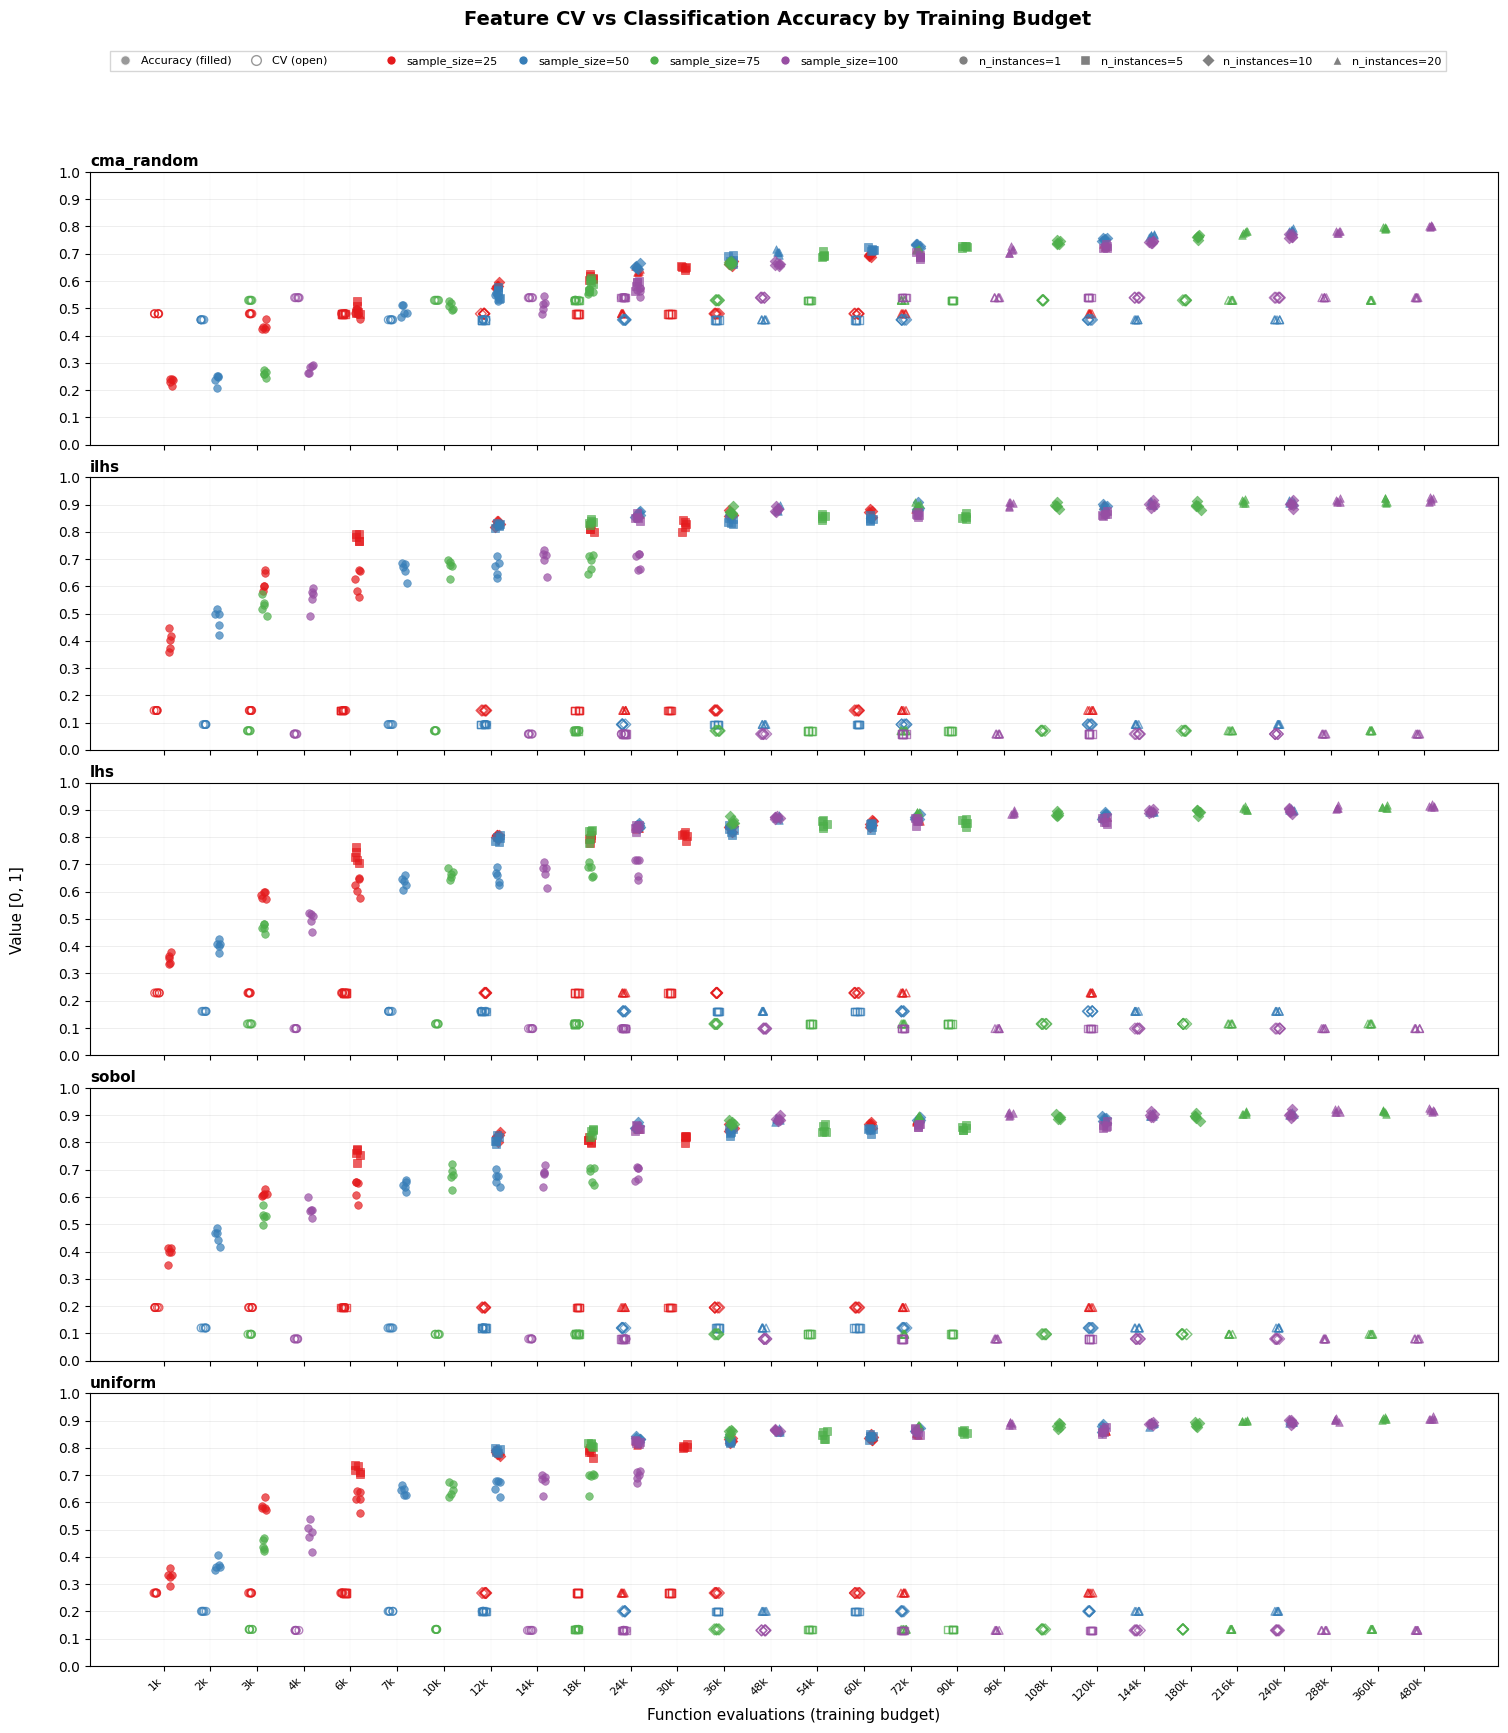

(<Figure size 1600x1800 with 5 Axes>,
 array([<Axes: title={'left': 'cma_random'}>,
        <Axes: title={'left': 'ilhs'}>, <Axes: title={'left': 'lhs'}>,
        <Axes: title={'left': 'sobol'}>,
        <Axes: title={'left': 'uniform'}, xlabel='Function evaluations (training budget)'>],
       dtype=object))

In [11]:
plot_cv_vs_accuracy(df)
##  instances per function: [1, 5, 10, 20]
## runs per instance [1, 3, 5]

In [17]:
# df[df.n_feval_train == 14400][columns].sort_values(by=["accuracy_allruns_mean"], ascending=False)

In [ ]:
# df[df.n_feval_train == 96000].sort_values(by=["accuracy_allruns_mean"], ascending=False)

In [16]:
import seaborn as sns
# sns.lineplot(data=df[df.sampling_strategy == "sobol"], x="accuracy_allruns_mean", y="cv_instance_median_mean")

In [ ]:
# Most efficient config per strategy (cheapest within 1% of best)
for s in df["sampling_strategy"].unique():
    sub = df[df["sampling_strategy"] == s]
    threshold = sub["accuracy_allruns_mean"].max() - 0.01
    print(sub[sub["accuracy_allruns_mean"] >= threshold].sort_values("n_feval_train").iloc[0])
    print()

## Dimension 5

In [13]:
table_pkl_dim5 = Path("~/t7ssd/featELA/dim5featEla/classification_subsample/subsample_results_table.pkl")
df_dim5 = pd.read_pickle(table_pkl_dim5)
df_dim5 = df_dim5.drop(df_dim5[df_dim5.sample_size_per_dim == 10].index)
df_dim5


,dimension,sampling_strategy,sample_size_per_dim,n_instances_train,n_runs_train,n_feval_train,fold,n_features,n_omitted_features,omitted_features,cv_instance_median_mean,cv_instance_median_median,cv_function_median_mean,cv_function_median_median,cv_training_folds_median_mean,cv_training_folds_median_median,accuracy_median,accuracy_allruns,consistency
0,5,cma_random,25,1,1,3000,0,51,1,ela_meta.quad_simple.cond,0.358806,0.332018,0.701261,0.342616,NaN,NaN,0.320312,0.282604,0.282604
1,5,cma_random,25,1,1,3000,1,51,1,ela_meta.quad_simple.cond,0.358806,0.332018,0.701261,0.342616,NaN,NaN,0.379688,0.285017,0.285017
2,5,cma_random,25,1,1,3000,2,51,1,ela_meta.quad_simple.cond,0.358806,0.332018,0.701261,0.342616,NaN,NaN,0.480729,0.298056,0.298056
3,5,cma_random,25,1,1,3000,3,51,1,ela_meta.quad_simple.cond,0.358806,0.332018,0.701261,0.342616,NaN,NaN,0.317188,0.270313,0.270313
4,5,cma_random,25,1,1,3000,4,51,1,ela_meta.quad_simple.cond,0.358806,0.332018,0.701261,0.342616,NaN,NaN,0.398958,0.291476,0.291476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,5,uniform,100,20,5,1200000,0,51,1,ela_meta.quad_simple.cond,0.185245,0.081503,0.539473,0.113519,NaN,NaN,0.986458,0.973142,0.973142
1196,5,uniform,100,20,5,1200000,1,51,1,ela_meta.quad_simple.cond,0.185245,0.081503,0.539473,0.113519,NaN,NaN,0.976042,0.965920,0.965920
1197,5,uniform,100,20,5,1200000,2,51,1,ela_meta.quad_simple.cond,0.185245,0.081503,0.539473,0.113519,NaN,NaN,0.983854,0.968993,0.968993
1198,5,uniform,100,20,5,1200000,3,51,1,ela_meta.quad_simple.cond,0.185245,0.081503,0.539473,0.113519,NaN,NaN,0.979688,0.969514,0.969514


In [ ]:
df_unique = df_dim5.drop_duplicates(subset=["sampling_strategy", "sample_size_per_dim"])
pivot = df_unique.pivot(index="sampling_strategy", columns="sample_size_per_dim",
                        values="cv_instance_median_mean")
pivot

In [ ]:
df_dim5["n_feval_train"].value_counts()


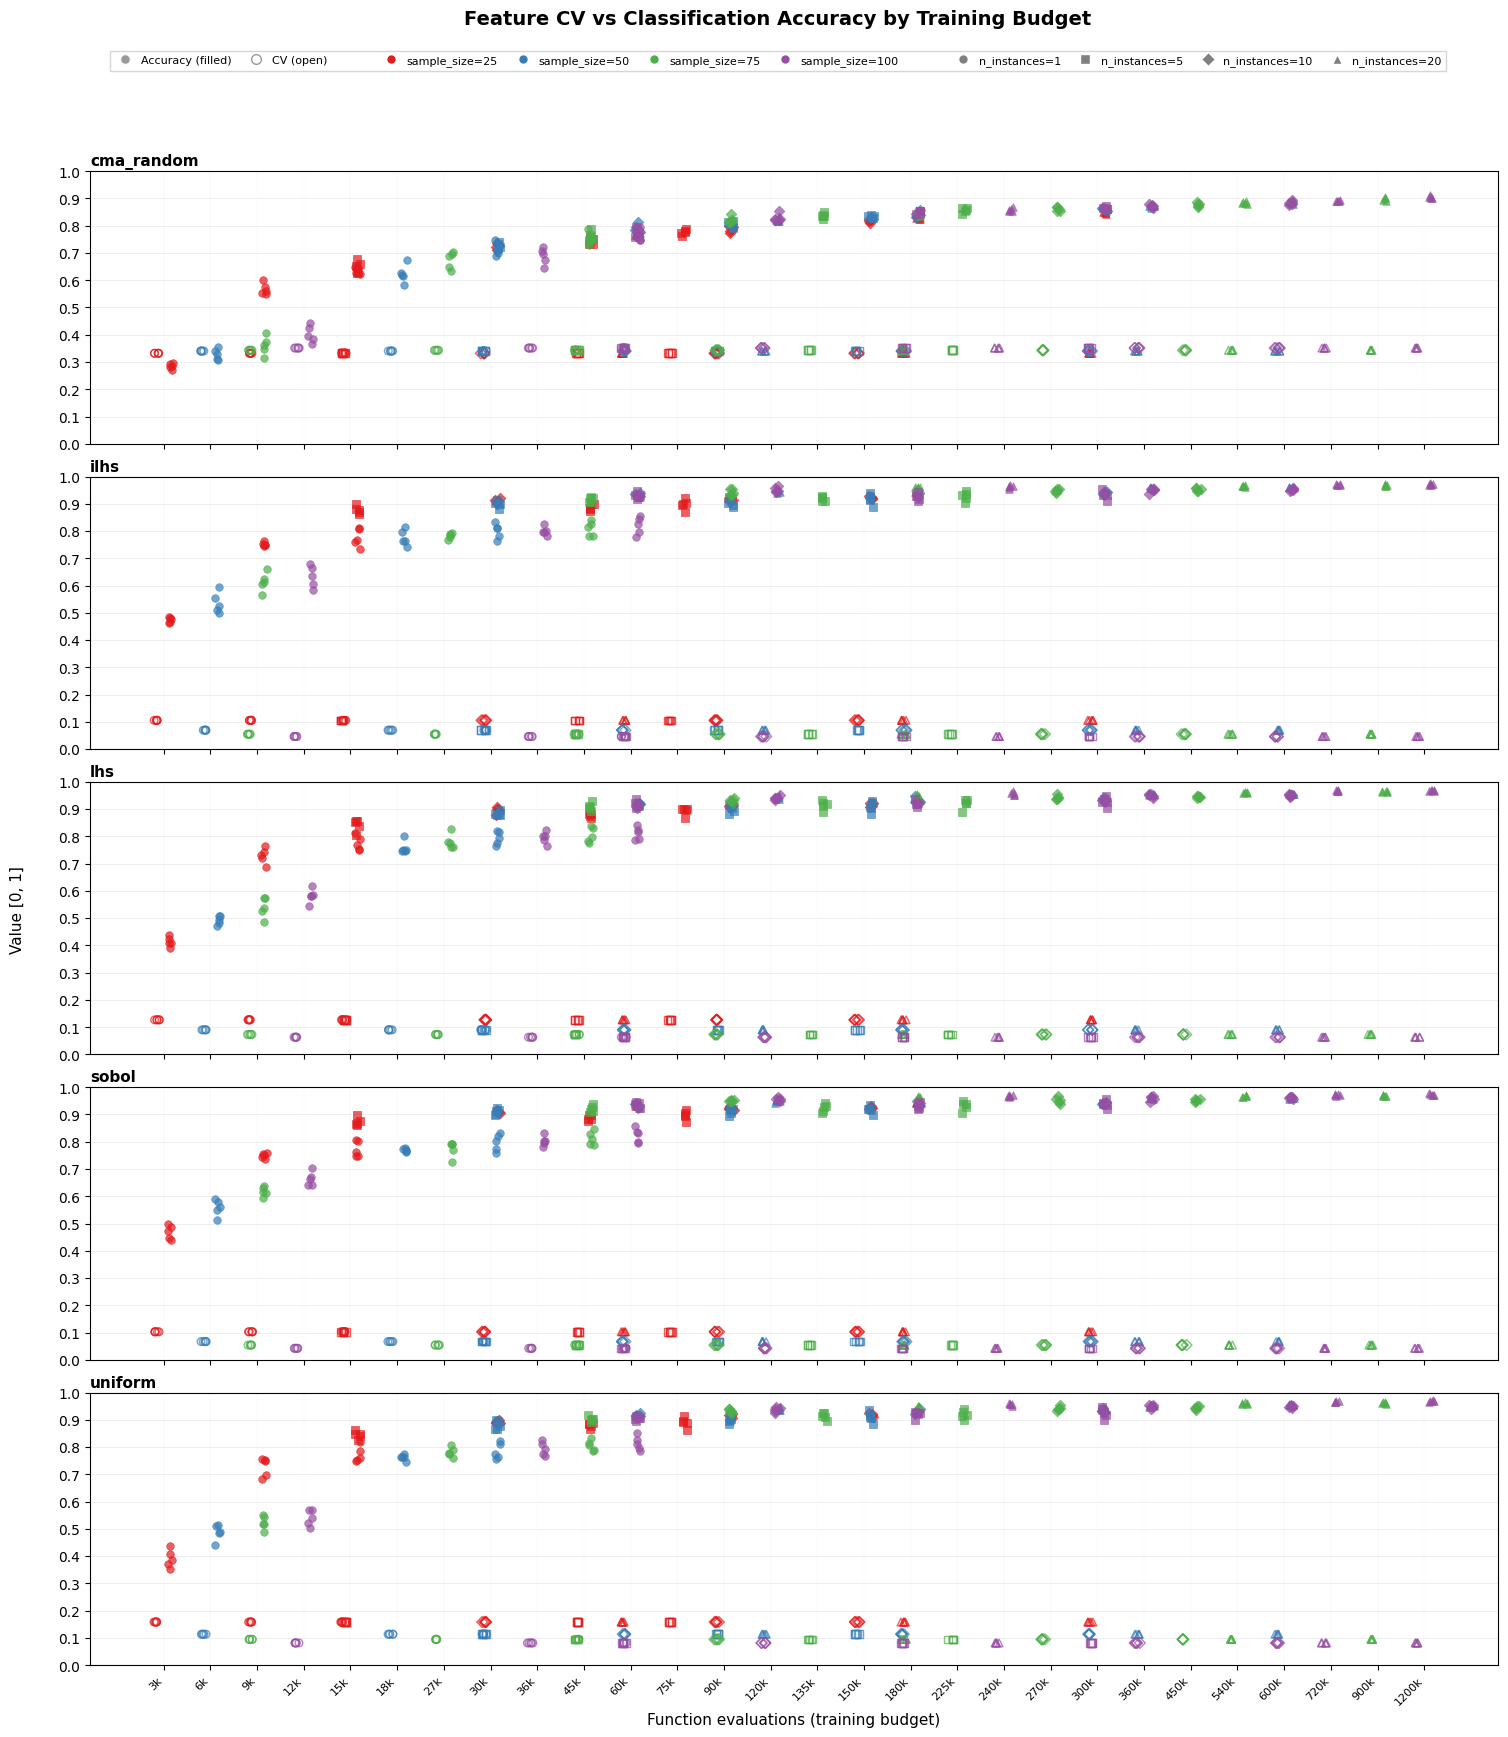

(<Figure size 1600x1800 with 5 Axes>,
 array([<Axes: title={'left': 'cma_random'}>,
        <Axes: title={'left': 'ilhs'}>, <Axes: title={'left': 'lhs'}>,
        <Axes: title={'left': 'sobol'}>,
        <Axes: title={'left': 'uniform'}, xlabel='Function evaluations (training budget)'>],
       dtype=object))

In [14]:
plot_cv_vs_accuracy(df_dim5)

In [ ]:
# Best config per strategy (highest accuracy)
df_dim5.loc[df_dim5.groupby("sampling_strategy")["accuracy_median_mean"].idxmax()]